In [1]:
from google.colab import files

uploaded = files.upload()

Saving dataset_A_PERFECT.csv to dataset_A_PERFECT.csv


In [2]:
from google.colab import files

uploaded = files.upload()

Saving dataset_B_SYNONYM.csv to dataset_B_SYNONYM.csv


In [3]:
from google.colab import files

uploaded = files.upload()

Saving dataset_C_LOGIC_ERROR.csv to dataset_C_LOGIC_ERROR.csv


Loading Sentence-BERT model...
Model loaded.

Saved: predictions_A_embed_final.csv
Saved: predictions_B_embed_final.csv
Saved: predictions_C_embed_final.csv

method3_embedded results
Threshold: 0.58
Accuracy A: 90.0%
Accuracy B: 30.0%
Accuracy C: 15.0%
---------------------------------------
False Alarm A: 10.0%
False Alarm B: 70.0%
Logic Error Recall C: 15.0%
---------------------------------------


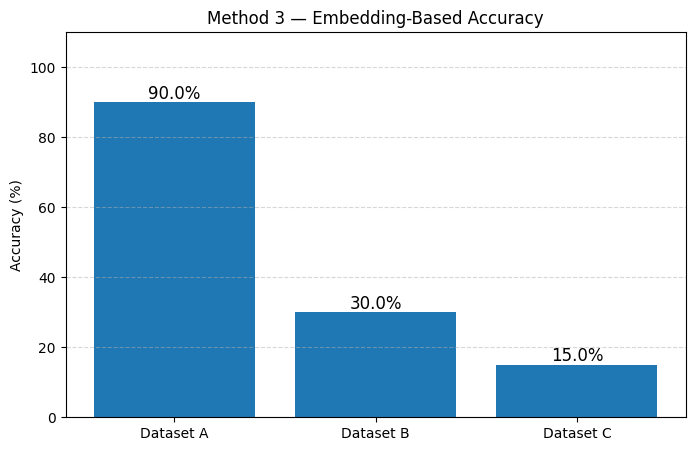

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# Method 3 — Embedding-based (Sentence-BERT)
#12/1/2026 started
#cues needs to be more? if yes, lets add more team!
 #(hello!!,just add which negations you may feel can add value)
 #(answer: thsoe are enough i guess )
 #(yes)
 #(yes, enough)
#notes: need to be checked before the 12/6/2026

!pip install sentence-transformers --quiet

import re
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

print("Loading Sentence-BERT model...")
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded.\n")

SIM_THRESHOLD = 0.58

CUES = [
    "not", "never", "forbidden", "must not", "cannot", "should not",
    "prevent", "restricted", "only", "exactly one", "at least one"
]

# Parsing the text

def parse_uml(uml_text):
    entities = re.findall(r"entity\s+(\w+)", uml_text, flags=re.IGNORECASE)
    relationships = re.findall(r"relationship\s+(\w+)", uml_text, flags=re.IGNORECASE)
    rel_pairs = re.findall(r"(\w+)\s*[-=]\w*[-=]\s*(\w+)", uml_text)
    return entities, relationships, rel_pairs

#to english
def uml_to_english(uml_text):
    text = (uml_text or "").replace("\n", " ")
    entities, relationships, rel_pairs = parse_uml(text)

    rel_map = {}
    for r, e in rel_pairs:
        rel_map.setdefault(r, set()).add(e)

    # fallback if relationship blocks are missing,(note:-) this is implemented, just for safety)
    if not relationships:
        if entities:
            return "Entities present: " + ", ".join(sorted(set(entities))) + "."
        return "No readable entities or relationships found."

    out = []
    for rel in relationships:
        if rel not in rel_map:
            continue

        targets = list(rel_map[rel])
        actor = next((t for t in targets if t.upper() != "SYSTEM"), "System")
        action = rel.lower().replace("_", " ")

        objects = [t for t in targets if t != actor and t.upper() != "SYSTEM"]
        obj_phrase = ", ".join(o.lower().replace("_", " ") for o in objects)

        if obj_phrase:
            sent = f"{actor.lower()} is responsible to {action} {obj_phrase}."
        else:
            sent = f"{actor.lower()} performs action: {action}."
        out.append(sent.capitalize())

    if out:
        return " ".join(out)

    if entities:
        return "Entities present: " + ", ".join(sorted(set(entities))) + "."
    return "Diagram could not be summarized."

def has_constraint_cue(requirement):
    req = (requirement or "").lower()
    return any(cue in req for cue in CUES)

def embed(text):
    return model.encode([text])[0]

def predict(requirement, plantuml, threshold=SIM_THRESHOLD):
    requirement = requirement or ""
    plantuml = plantuml or ""

    if has_constraint_cue(requirement):
        return "MISMATCH", -1.0

    uml_english = uml_to_english(plantuml)
    req_vec = embed(requirement)
    uml_vec = embed(uml_english)

    score = float(cosine_similarity([req_vec], [uml_vec])[0][0])
    label = "MATCH" if score >= threshold else "MISMATCH"
    return label, score

# reqyuurement and plantuml
def run_and_save(in_csv, out_csv):
    df = pd.read_csv(in_csv)

    preds = []
    confs = []
    for req, uml in zip(df["Requirement"], df["PlantUML"]):
        label, score = predict(str(req), str(uml))
        preds.append(label)
        confs.append(round(score, 4))

    df["Prediction"] = preds
    df["Confidence"] = confs
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
    return df

def accuracy(df):
    return round(((df["Prediction"] == df["Label"]).sum() / len(df)) * 100, 2)

def false_alarm_rate(df):
    fa = ((df["Label"] == "MATCH") & (df["Prediction"] == "MISMATCH")).sum()
    return round((fa / len(df)) * 100, 2)

def logic_error_recall(df):
    det = ((df["Label"] == "MISMATCH") & (df["Prediction"] == "MISMATCH")).sum()
    return round((det / len(df)) * 100, 2)

# main execution block

A = "dataset_A_PERFECT.csv"
B = "dataset_B_SYNONYM.csv"
C = "dataset_C_LOGIC_ERROR.csv"

dfA = run_and_save(A, "predictions_A_embed_final.csv")
dfB = run_and_save(B, "predictions_B_embed_final.csv")
dfC = run_and_save(C, "predictions_C_embed_final.csv")

acc_A, acc_B, acc_C = accuracy(dfA), accuracy(dfB), accuracy(dfC)
fa_A, fa_B = false_alarm_rate(dfA), false_alarm_rate(dfB)
recall_C = logic_error_recall(dfC)

print("\nmethod3_embedded results")
print(f"Threshold: {SIM_THRESHOLD}")
print(f"Accuracy A: {acc_A}%")
print(f"Accuracy B: {acc_B}%")
print(f"Accuracy C: {acc_C}%")
print("---------------------------------------")
print(f"False Alarm A: {fa_A}%")
print(f"False Alarm B: {fa_B}%")
print(f"Logic Error Recall C: {recall_C}%")
print("---------------------------------------")

# Plotting graphs

labels = ["Dataset A", "Dataset B", "Dataset C"]
values = [acc_A, acc_B, acc_C]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)

for b in bars:
    v = b.get_height()
    plt.text(b.get_x() + b.get_width()/2, v + 1, f"{v:.1f}%", ha="center", fontsize=12)

plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("Method 3 — Embedding-Based Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

# Direct downloading the outputs (csv formats)

from google.colab import files
files.download("predictions_A_embed_final.csv")
files.download("predictions_B_embed_final.csv")
files.download("predictions_C_embed_final.csv")
